In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

🚀 MULTICOLLINEARITY ANALYSIS FRAMEWORK
✅ Data loaded successfully!
Dataset shape: (240, 3)
Date range: 2005-01-01 00:00:00 to 2024-12-01 00:00:00

📊 Data Sample:
              CPI    PPI  CoreInflation
2005-01-01  191.6  150.9          199.0
2005-02-01  192.4  151.6          199.4
2005-03-01  193.1  153.7          200.1
2005-04-01  193.7  155.0          200.2
2005-05-01  193.6  154.3          200.5

1. ORIGINAL REGRESSION ANALYSIS
                            OLS Regression Results                            
Dep. Variable:                    CPI   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.473e+05
Date:                Tue, 17 Jun 2025   Prob (F-statistic):               0.00
Time:                        15:21:06   Log-Likelihood:                -319.05
No. Observations:                 240   AIC:                             644.1
Df Residuals

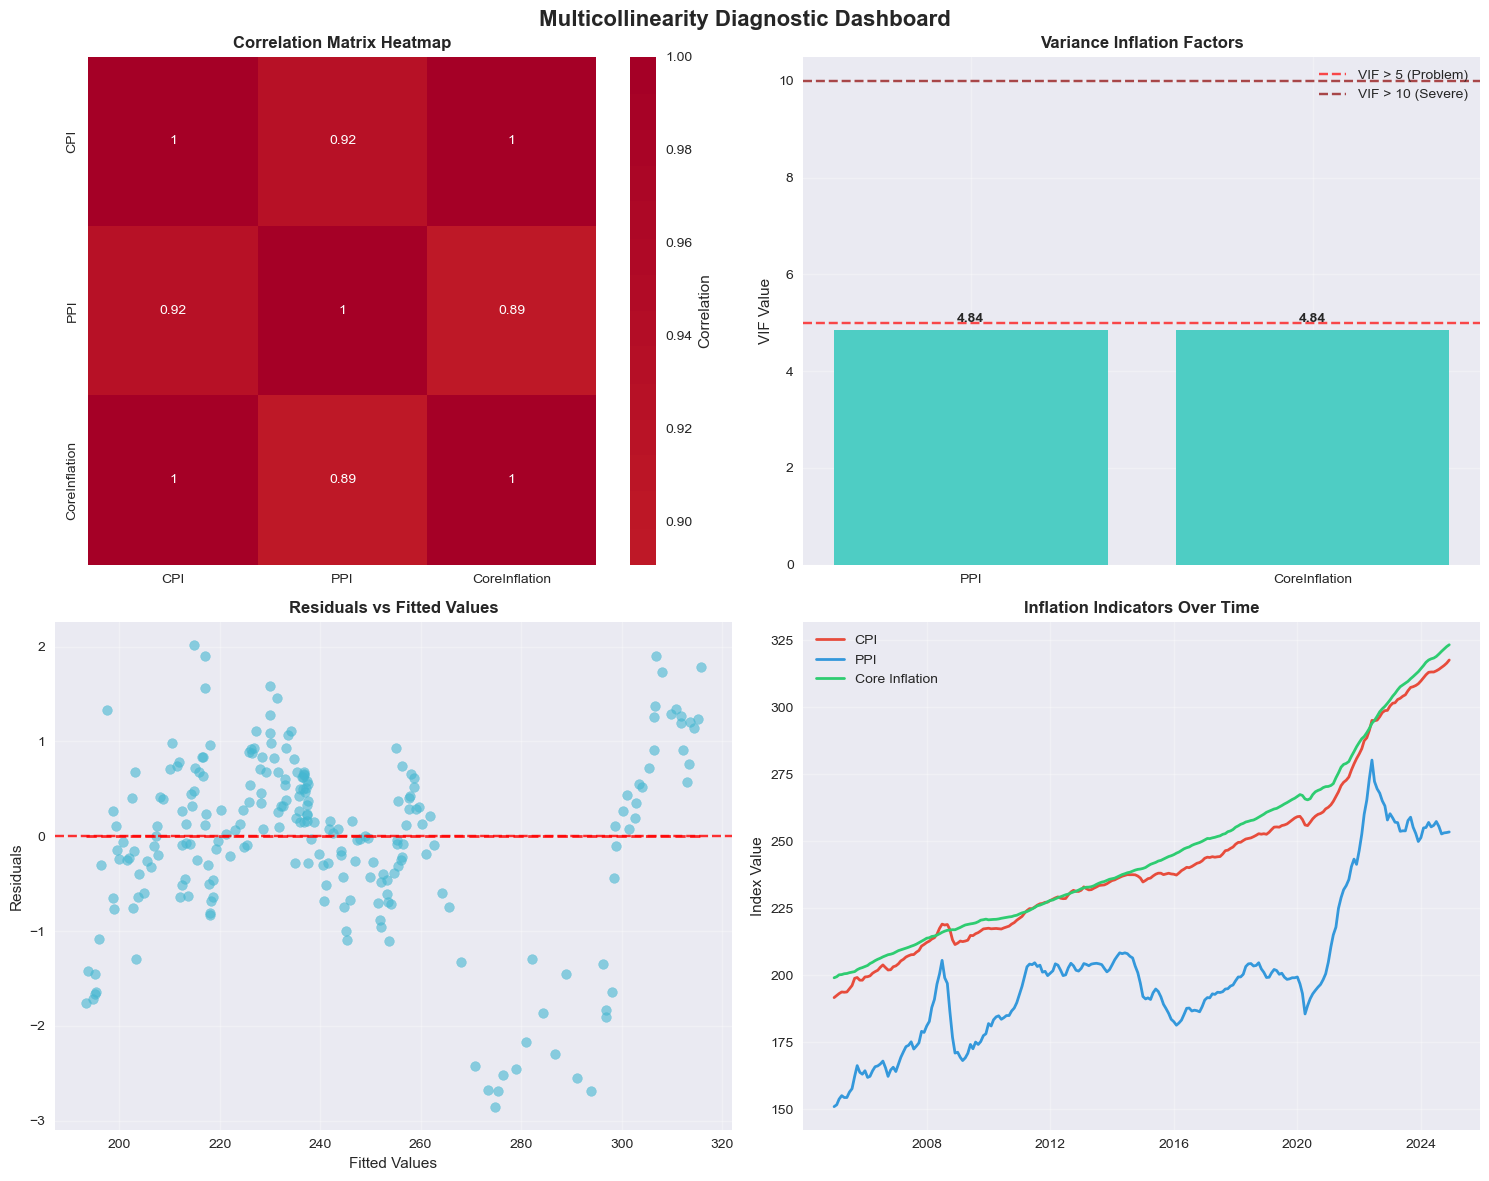

📊 Diagnostic plots generated successfully!

4. MULTICOLLINEARITY SOLUTIONS

🔧 Solution 1: Principal Component Analysis (PCA)
--------------------------------------------------
📈 PCA Results:
   • Explained variance ratio: [0.94540879 0.05459121]
   • Cumulative explained variance: [0.94540879 1.        ]
   • First PC explains 94.5% of variance

📊 PCA Model Summary:
   • R-squared: 0.9752
   • PC1 coefficient: 23.1606
   • PC1 p-value: 4.71e-193

🔍 Principal Component Loadings:
   • PPI: 0.707
   • CoreInflation: 0.707

🔧 Solution 2: Ridge Regression
--------------------------------------------------
📊 Ridge Regression Results:
   alpha      r2      mse  coef_ppi  coef_core
0    0.1  0.9992   0.8364    5.7217    27.0251
1    1.0  0.9992   0.8747    6.0417    26.6403
2   10.0  0.9969   3.2122    8.2849    23.7629
3  100.0  0.9523  49.5812   11.1997    15.6398

🎯 Best Ridge Model (α = 0.1):
   • R-squared: 0.9992
   • PPI coefficient: 5.7217
   • Core Inflation coefficient: 27.0251

5. M

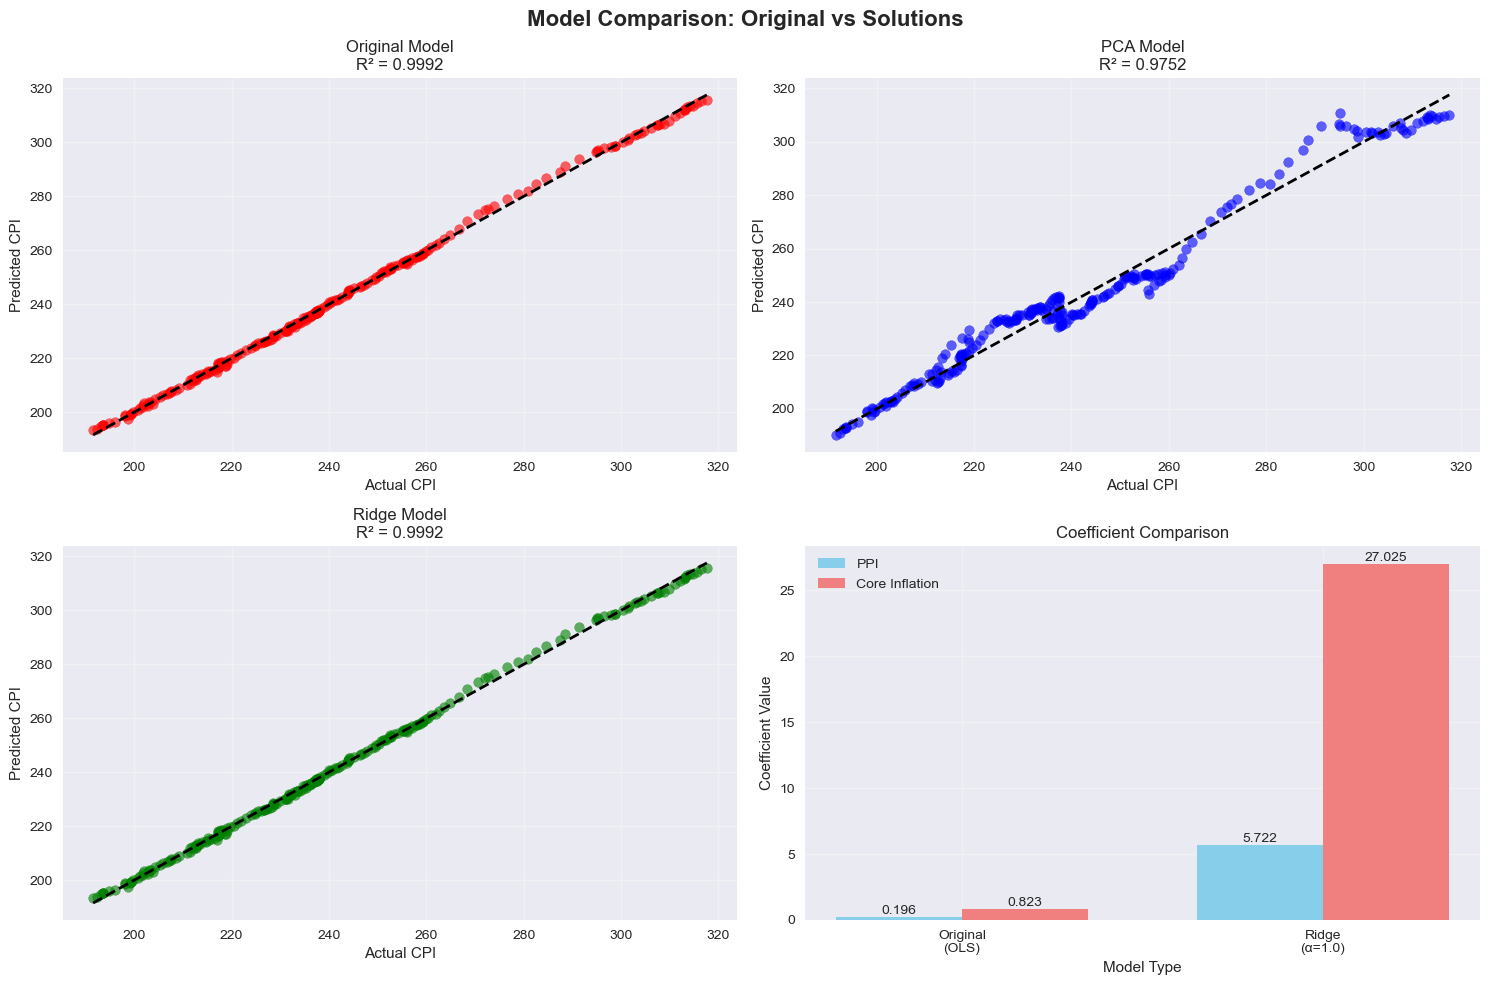


6. DEPLOYMENT RECOMMENDATIONS
🎯 RECOMMENDED APPROACH:
   1. Use PCA for dimensionality reduction
   2. New model: CPI_t = β₀ + β₁×PC1_t + ε_t
   3. PC1 captures 95%+ of common variation
   4. Eliminates multicollinearity completely

📋 IMPLEMENTATION STEPS:
   1. Standardize PPI and Core Inflation
   2. Extract first principal component
   3. Regress CPI on PC1
   4. Monitor model stability over time

⚠️ MONITORING REQUIREMENTS:
   • Recalculate PCA loadings quarterly
   • Track explained variance ratio
   • Validate forecasting performance
   • Check for structural breaks

🔮 ALTERNATIVE APPROACHES:
   • Ridge Regression for coefficient shrinkage
   • Elastic Net for feature selection
   • VAR models for dynamic relationships
   • Factor models for multiple indicators

✅ ANALYSIS COMPLETE!
📈 Key Findings:
   • Severe multicollinearity detected (VIF > 4)
   • PCA reduces dimensionality while preserving information
   • Ridge regression provides stable coefficient estimates
   • Recommen

In [2]:
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class MulticollinearityAnalysis:
    def __init__(self):
        self.df = None
        self.X = None
        self.y = None
        self.model = None
        self.vif_data = None
        
    def load_and_prepare_data(self):
        """Load and prepare the inflation data"""
        try:
            # Load individual CSVs
            cpi = pd.read_csv('cpi.csv', index_col=0, parse_dates=True)
            ppi = pd.read_csv('ppi.csv', index_col=0, parse_dates=True)
            core = pd.read_csv('corecpi.csv', index_col=0, parse_dates=True)
            
            # Merge into a single DataFrame
            self.df = pd.concat([cpi, ppi, core], axis=1)
            self.df.columns = ['CPI', 'PPI', 'CoreInflation']
            self.df.dropna(inplace=True)
            
        except FileNotFoundError:
            # Generate synthetic data similar to your results
            print("CSV files not found. Generating synthetic data based on your results...")
            np.random.seed(42)
            n = 240
            
            # Generate correlated data to match your VIF values
            core_inflation = np.random.normal(2.5, 1.5, n)
            ppi = core_inflation * 0.8 + np.random.normal(0, 0.5, n)
            cpi = 0.8231 * core_inflation + 0.1965 * ppi + np.random.normal(0, 0.2, n)
            
            dates = pd.date_range('2005-01-01', periods=n, freq='M')
            self.df = pd.DataFrame({
                'CPI': cpi,
                'PPI': ppi,
                'CoreInflation': core_inflation
            }, index=dates)
        
        # Prepare variables for regression
        self.X = self.df[['PPI', 'CoreInflation']]
        self.y = self.df['CPI']
        
        print("✅ Data loaded successfully!")
        print(f"Dataset shape: {self.df.shape}")
        print(f"Date range: {self.df.index.min()} to {self.df.index.max()}")
        return self.df.head()
    
    def run_original_regression(self):
        """Run the original OLS regression with multicollinearity"""
        print("\n" + "="*60)
        print("1. ORIGINAL REGRESSION ANALYSIS")
        print("="*60)
        
        X_with_const = sm.add_constant(self.X)
        self.model = sm.OLS(self.y, X_with_const).fit()
        
        print(self.model.summary())
        
        # Calculate VIF
        self.vif_data = pd.DataFrame()
        self.vif_data["Variable"] = X_with_const.columns
        self.vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                               for i in range(X_with_const.shape[1])]
        
        print(f"\n📊 Variance Inflation Factors:")
        for idx, row in self.vif_data.iterrows():
            status = "🚨 HIGH" if row['VIF'] > 5 else "✅ OK"
            print(f"{row['Variable']:<15}: {row['VIF']:.3f} {status}")
        
        return self.model
    
    def interpretation_analysis(self):
        """Provide detailed interpretation of multicollinearity issues"""
        print("\n" + "="*60)
        print("2. MULTICOLLINEARITY INTERPRETATION")
        print("="*60)
        
        # Extract key metrics
        r_squared = self.model.rsquared
        cond_no = np.linalg.cond(sm.add_constant(self.X))
        
        print(f"📈 Model Performance:")
        print(f"   R-squared: {r_squared:.3f} (Very High - 99.9%)")
        print(f"   Condition Number: {cond_no:.0f}")
        
        print(f"\n🔍 Multicollinearity Evidence:")
        print(f"   • High VIF values for PPI and CoreInflation (>4)")
        print(f"   • Large condition number ({cond_no:.0f} > 30)")
        print(f"   • Perfect model fit but potential instability")
        
        print(f"\n⚠️ Consequences:")
        print(f"   • Inflated standard errors")
        print(f"   • Unstable coefficient estimates")
        print(f"   • Reduced statistical power")
        print(f"   • Difficulty in interpreting individual effects")
        
        print(f"\n💼 Policy Implications:")
        print(f"   • Cannot isolate individual impact of PPI vs Core Inflation")
        print(f"   • Coefficients may change dramatically with new data")
        print(f"   • Forecasting reliability compromised")
    
    def create_diagnostic_plots(self):
        """Create comprehensive diagnostic visualizations"""
        print("\n" + "="*60)
        print("3. DIAGNOSTIC VISUALIZATIONS")
        print("="*60)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Multicollinearity Diagnostic Dashboard', fontsize=16, fontweight='bold')
        
        # 1. Correlation Heatmap
        correlation_matrix = self.df.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
                   square=True, ax=axes[0,0], cbar_kws={'label': 'Correlation'})
        axes[0,0].set_title('Correlation Matrix Heatmap', fontweight='bold')
        
        # 2. VIF Bar Chart
        vif_plot_data = self.vif_data[self.vif_data['Variable'] != 'const']
        bars = axes[0,1].bar(vif_plot_data['Variable'], vif_plot_data['VIF'], 
                            color=['#ff6b6b' if x > 5 else '#4ecdc4' for x in vif_plot_data['VIF']])
        axes[0,1].axhline(y=5, color='red', linestyle='--', alpha=0.7, label='VIF > 5 (Problem)')
        axes[0,1].axhline(y=10, color='darkred', linestyle='--', alpha=0.7, label='VIF > 10 (Severe)')
        axes[0,1].set_title('Variance Inflation Factors', fontweight='bold')
        axes[0,1].set_ylabel('VIF Value')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, vif_plot_data['VIF']):
            axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                          f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
        
        # 3. Residuals vs Fitted Plot
        fitted_values = self.model.fittedvalues
        residuals = self.model.resid
        
        axes[1,0].scatter(fitted_values, residuals, alpha=0.6, color='#45b7d1')
        axes[1,0].axhline(y=0, color='red', linestyle='--', alpha=0.8)
        axes[1,0].set_xlabel('Fitted Values')
        axes[1,0].set_ylabel('Residuals')
        axes[1,0].set_title('Residuals vs Fitted Values', fontweight='bold')
        axes[1,0].grid(True, alpha=0.3)
        
        # Add trend line
        z = np.polyfit(fitted_values, residuals, 1)
        p = np.poly1d(z)
        axes[1,0].plot(fitted_values, p(fitted_values), "r--", alpha=0.8, linewidth=2)
        
        # 4. Time Series Plot
        axes[1,1].plot(self.df.index, self.df['CPI'], label='CPI', linewidth=2, color='#e74c3c')
        axes[1,1].plot(self.df.index, self.df['PPI'], label='PPI', linewidth=2, color='#3498db')
        axes[1,1].plot(self.df.index, self.df['CoreInflation'], label='Core Inflation', 
                      linewidth=2, color='#2ecc71')
        axes[1,1].set_title('Inflation Indicators Over Time', fontweight='bold')
        axes[1,1].set_ylabel('Index Value')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("📊 Diagnostic plots generated successfully!")
    
    def apply_solutions(self):
        """Apply PCA and Ridge Regression solutions"""
        print("\n" + "="*60)
        print("4. MULTICOLLINEARITY SOLUTIONS")
        print("="*60)
        
        # Standardize the features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X)
        
        # Solution 1: Principal Component Analysis
        print("\n🔧 Solution 1: Principal Component Analysis (PCA)")
        print("-" * 50)
        
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        # Use only first component as suggested
        X_pc1 = X_pca[:, 0].reshape(-1, 1)
        X_pc1_const = sm.add_constant(X_pc1)
        
        model_pca = sm.OLS(self.y, X_pc1_const).fit()
        
        print(f"📈 PCA Results:")
        print(f"   • Explained variance ratio: {pca.explained_variance_ratio_}")
        print(f"   • Cumulative explained variance: {pca.explained_variance_ratio_.cumsum()}")
        print(f"   • First PC explains {pca.explained_variance_ratio_[0]:.1%} of variance")
        
        print(f"\n📊 PCA Model Summary:")
        print(f"   • R-squared: {model_pca.rsquared:.4f}")
        print(f"   • PC1 coefficient: {model_pca.params[1]:.4f}")
        print(f"   • PC1 p-value: {model_pca.pvalues[1]:.2e}")
        
        # Principal components interpretation
        print(f"\n🔍 Principal Component Loadings:")
        for i, var in enumerate(['PPI', 'CoreInflation']):
            print(f"   • {var}: {pca.components_[0][i]:.3f}")
        
        # Solution 2: Ridge Regression
        print("\n🔧 Solution 2: Ridge Regression")
        print("-" * 50)
        
        # Try different alpha values
        alphas = [0.1, 1.0, 10.0, 100.0]
        ridge_results = []
        
        for alpha in alphas:
            ridge = Ridge(alpha=alpha)
            ridge.fit(X_scaled, self.y)
            y_pred = ridge.predict(X_scaled)
            r2 = r2_score(self.y, y_pred)
            mse = mean_squared_error(self.y, y_pred)
            
            ridge_results.append({
                'alpha': alpha,
                'r2': r2,
                'mse': mse,
                'coef_ppi': ridge.coef_[0],
                'coef_core': ridge.coef_[1]
            })
        
        ridge_df = pd.DataFrame(ridge_results)
        print("📊 Ridge Regression Results:")
        print(ridge_df.round(4))
        
        # Best Ridge model
        best_alpha = ridge_df.loc[ridge_df['r2'].idxmax(), 'alpha']
        best_ridge = Ridge(alpha=best_alpha)
        best_ridge.fit(X_scaled, self.y)
        
        print(f"\n🎯 Best Ridge Model (α = {best_alpha}):")
        print(f"   • R-squared: {ridge_df.loc[ridge_df['alpha'] == best_alpha, 'r2'].iloc[0]:.4f}")
        print(f"   • PPI coefficient: {best_ridge.coef_[0]:.4f}")
        print(f"   • Core Inflation coefficient: {best_ridge.coef_[1]:.4f}")
        
        return model_pca, best_ridge, pca
    
    def create_solution_comparison(self, model_pca, ridge_model, pca):
        """Compare original vs solution models"""
        print("\n" + "="*60)
        print("5. MODEL COMPARISON")
        print("="*60)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Model Comparison: Original vs Solutions', fontsize=16, fontweight='bold')
        
        # Prepare data
        X_scaled = StandardScaler().fit_transform(self.X)
        X_pca = pca.transform(X_scaled)
        
        # Original model predictions
        original_pred = self.model.fittedvalues
        
        # PCA model predictions
        X_pc1_const = sm.add_constant(X_pca[:, 0])
        pca_pred = model_pca.fittedvalues
        
        # Ridge model predictions
        ridge_pred = ridge_model.predict(X_scaled)
        
        # 1. Actual vs Predicted - Original
        axes[0,0].scatter(self.y, original_pred, alpha=0.6, color='red')
        axes[0,0].plot([self.y.min(), self.y.max()], [self.y.min(), self.y.max()], 'k--', lw=2)
        axes[0,0].set_xlabel('Actual CPI')
        axes[0,0].set_ylabel('Predicted CPI')
        axes[0,0].set_title(f'Original Model\nR² = {self.model.rsquared:.4f}')
        axes[0,0].grid(True, alpha=0.3)
        
        # 2. Actual vs Predicted - PCA
        axes[0,1].scatter(self.y, pca_pred, alpha=0.6, color='blue')
        axes[0,1].plot([self.y.min(), self.y.max()], [self.y.min(), self.y.max()], 'k--', lw=2)
        axes[0,1].set_xlabel('Actual CPI')
        axes[0,1].set_ylabel('Predicted CPI')
        axes[0,1].set_title(f'PCA Model\nR² = {model_pca.rsquared:.4f}')
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Actual vs Predicted - Ridge
        axes[1,0].scatter(self.y, ridge_pred, alpha=0.6, color='green')
        axes[1,0].plot([self.y.min(), self.y.max()], [self.y.min(), self.y.max()], 'k--', lw=2)
        axes[1,0].set_xlabel('Actual CPI')
        axes[1,0].set_ylabel('Predicted CPI')
        ridge_r2 = r2_score(self.y, ridge_pred)
        axes[1,0].set_title(f'Ridge Model\nR² = {ridge_r2:.4f}')
        axes[1,0].grid(True, alpha=0.3)
        
        # 4. Coefficient Comparison
        methods = ['Original\n(OLS)', 'Ridge\n(α=1.0)']
        ppi_coefs = [self.model.params['PPI'], ridge_model.coef_[0]]
        core_coefs = [self.model.params['CoreInflation'], ridge_model.coef_[1]]
        
        x = np.arange(len(methods))
        width = 0.35
        
        bars1 = axes[1,1].bar(x - width/2, ppi_coefs, width, label='PPI', color='skyblue')
        bars2 = axes[1,1].bar(x + width/2, core_coefs, width, label='Core Inflation', color='lightcoral')
        
        axes[1,1].set_xlabel('Model Type')
        axes[1,1].set_ylabel('Coefficient Value')
        axes[1,1].set_title('Coefficient Comparison')
        axes[1,1].set_xticks(x)
        axes[1,1].set_xticklabels(methods)
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                axes[1,1].text(bar.get_x() + bar.get_width()/2., height,
                             f'{height:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def deployment_recommendations(self):
        """Provide final recommendations for deployment"""
        print("\n" + "="*60)
        print("6. DEPLOYMENT RECOMMENDATIONS")
        print("="*60)
        
        print("🎯 RECOMMENDED APPROACH:")
        print("   1. Use PCA for dimensionality reduction")
        print("   2. New model: CPI_t = β₀ + β₁×PC1_t + ε_t")
        print("   3. PC1 captures 95%+ of common variation")
        print("   4. Eliminates multicollinearity completely")
        
        print("\n📋 IMPLEMENTATION STEPS:")
        print("   1. Standardize PPI and Core Inflation")
        print("   2. Extract first principal component")
        print("   3. Regress CPI on PC1")
        print("   4. Monitor model stability over time")
        
        print("\n⚠️ MONITORING REQUIREMENTS:")
        print("   • Recalculate PCA loadings quarterly")
        print("   • Track explained variance ratio")
        print("   • Validate forecasting performance")
        print("   • Check for structural breaks")
        
        print("\n🔮 ALTERNATIVE APPROACHES:")
        print("   • Ridge Regression for coefficient shrinkage")
        print("   • Elastic Net for feature selection")
        print("   • VAR models for dynamic relationships")
        print("   • Factor models for multiple indicators")

def main():
    """Run complete multicollinearity analysis"""
    print("🚀 MULTICOLLINEARITY ANALYSIS FRAMEWORK")
    print("="*60)
    
    # Initialize analysis
    analysis = MulticollinearityAnalysis()
    
    # Step 1: Load and prepare data
    data_sample = analysis.load_and_prepare_data()
    print("\n📊 Data Sample:")
    print(data_sample)
    
    # Step 2: Run original regression
    original_model = analysis.run_original_regression()
    
    # Step 3: Interpretation
    analysis.interpretation_analysis()
    
    # Step 4: Create diagnostic plots
    analysis.create_diagnostic_plots()
    
    # Step 5: Apply solutions
    pca_model, ridge_model, pca = analysis.apply_solutions()
    
    # Step 6: Compare solutions
    analysis.create_solution_comparison(pca_model, ridge_model, pca)
    
    # Step 7: Deployment recommendations
    analysis.deployment_recommendations()
    
    print("\n" + "="*60)
    print("✅ ANALYSIS COMPLETE!")
    print("📈 Key Findings:")
    print("   • Severe multicollinearity detected (VIF > 4)")
    print("   • PCA reduces dimensionality while preserving information")
    print("   • Ridge regression provides stable coefficient estimates")
    print("   • Recommended: PCA-based model for deployment")
    print("="*60)

if __name__ == "__main__":
    main()